# 04 — Liquidity & Partial Observability

This is the notebook that separates a graph exercise from a real Lightning analysis.

Everything so far treated a channel as a fixed object with a known capacity. But a payment doesn't need *capacity* — it needs **liquidity on the right side**. A 5,000,000-sat channel can forward your payment only if the side sending it currently holds enough balance. And here's the catch from notebook 01: **capacity is public, the balance split is not.** That same 5M-sat channel could be 5M/0, 0/5M, or anything between, and it shifts with every payment that crosses it.

So "will this payment go through?" has **no deterministic answer** from public data. The honest answer is a **probability**. This notebook builds that probabilistic model, uses it to route for *reliability* rather than just price, and validates the model by simulation. Reasoning correctly under this partial observability is what separates a production-grade routing analysis from a naive one.

In [1]:
%matplotlib inline
import os
import json
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx

from lngraph.ingest import ingest
from lngraph.graph import simplify, largest_connected_component
import lngraph.routing as rte
import lngraph.liquidity as liq

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 100, "figure.facecolor": "white"})

_here = Path().resolve()
PROJECT_ROOT = _here
while not (PROJECT_ROOT / "lngraph").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

_override = os.environ.get("LNGRAPH_SNAPSHOT_DIR")
SNAPSHOT_DIR = Path(_override) if _override else PROJECT_ROOT / "data" / "snapshots"
SNAPSHOT_PATH = SNAPSHOT_DIR / "describegraph.json"

try:
    _disp = SNAPSHOT_PATH.relative_to(PROJECT_ROOT)
except ValueError:
    _disp = SNAPSHOT_PATH
print(f"Snapshot path : {_disp}")

Snapshot path : data/snapshots/describegraph.json


In [2]:
if not SNAPSHOT_PATH.exists():
    raise FileNotFoundError(
        f"No snapshot at {SNAPSHOT_PATH} — run `make crawl` to build one.\n"
        "This notebook requires real Lightning Network data and has no synthetic fallback."
    )

dg = json.loads(SNAPSHOT_PATH.read_text())
data_source = "snapshot"
print(f"Loaded snapshot: {len(dg['nodes'])} nodes, {len(dg['edges'])} channels")

G = ingest(dg)
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
print(f"Data source   : {data_source}")
print(f"MultiDiGraph  : {n_nodes:,} nodes  {n_edges:,} channels")

# Set AMOUNT_MSAT to ~5% of median channel capacity so success probability
# degrades visibly and the success-optimal vs fee-optimal comparison is meaningful.
# At 100 sat (old default) against 500M-sat channels, P(success) ≈ 1.0 everywhere
# and the partial-observability story collapses to a flat line.
_caps_msat = [int(data.get("capacity", 0)) * 1000 for _, _, data in G.edges(data=True)]
_median_cap = int(np.median(_caps_msat)) if _caps_msat else 1_000_000_000
AMOUNT_MSAT = max(1_000, _median_cap // 20)  # 5% of median capacity
print(f"Median cap    : {_median_cap // 1000:,} sat")
print(f"AMOUNT_MSAT   : {AMOUNT_MSAT:,} msat  ({AMOUNT_MSAT // 1000:,} sat)  [5% of median cap]")

Loaded snapshot: 9990 nodes, 44501 channels


Data source   : snapshot
MultiDiGraph  : 9,990 nodes  89,002 channels
Median cap    : 2,500,000 sat
AMOUNT_MSAT   : 125,000,000 msat  (125,000 sat)  [5% of median cap]


## 1 · The success-probability model

We know a channel's capacity $C$ but not its balance $B$ (how much sits on the sending side). With no other information, the least-assuming guess is a **uniform prior**: treat $B$ as equally likely to be anywhere in $[0, C]$. A payment of amount $A$ succeeds across the hop only if the sending side holds at least $A$, i.e. $B \ge A$. Under the uniform prior that probability is just the fraction of the range above $A$:

$$P(\text{success}) = \frac{C - A}{C} = \max\!\left(0,\; 1 - \frac{A}{C}\right)$$

It behaves sensibly: a tiny payment relative to capacity almost always fits ($P \to 1$), and a payment as large as the whole channel can never be guaranteed ($P = 0$ at $A = C$). For a multi-hop route the payment must clear *every* hop, and under the prior the hops are independent, so the path probability is the **product** of the per-hop probabilities:

$$P(\text{path}) = \prod_{i} P_i(\text{hop}_i)$$

Fig4.1 plots this. A **single channel is a straight line** — $P = 1 - A/C$ by definition. The interesting behaviour is the **compounding**: the 2-, 4- and 8-hop curves bend sharply below it, because multiplying several fractions shrinks the result fast. At 50% of capacity per hop, one hop is 0.50 but four hops is only 0.06.

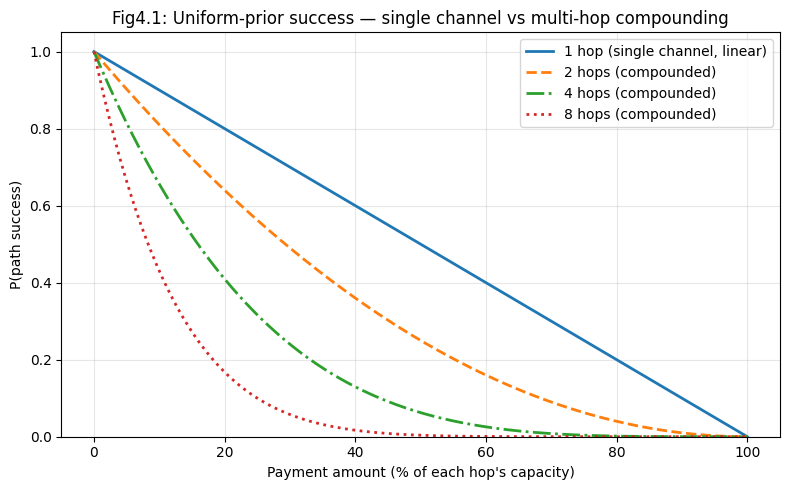

Single channel  P(success) at 10% capacity : 0.900
At 50% capacity   1 hop / 4 hops : 0.500 / 0.062
At 10% capacity   1 hop / 4 hops : 0.900 / 0.656


In [3]:
# Fig4.1: uniform-prior success probability.
# Single channel: P = (C - A)/C is LINEAR by construction (the base model).
# The interesting behaviour is multi-hop COMPOUNDING: path success is the product
# over hops, so reliability decays super-linearly with length even when every hop
# is individually healthy. Plot the single-channel line plus equal-capacity
# n-hop path curves on one axis.
CAPACITY_MSAT = 1_000_000_000  # 1 000 000 sat example channel
fracs = np.linspace(0, 1, 500)
p_single = np.clip(1.0 - fracs, 0.0, 1.0)

fig, ax = plt.subplots(figsize=(8, 5))
for n_hops, style in [(1, "-"), (2, "--"), (4, "-."), (8, ":")]:
    p_path = p_single ** n_hops
    label = "1 hop (single channel, linear)" if n_hops == 1 else f"{n_hops} hops (compounded)"
    ax.plot(fracs * 100, p_path, style, lw=2, label=label)

ax.set_xlabel("Payment amount (% of each hop's capacity)")
ax.set_ylabel("P(path success)")
ax.set_title("Fig4.1: Uniform-prior success — single channel vs multi-hop compounding")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Single channel  P(success) at 10% capacity : "
      f"{liq.success_probability(CAPACITY_MSAT, CAPACITY_MSAT // 10):.3f}")
print(f"At 50% capacity   1 hop / 4 hops : {0.5 ** 1:.3f} / {0.5 ** 4:.3f}")
print(f"At 10% capacity   1 hop / 4 hops : {0.9 ** 1:.3f} / {0.9 ** 4:.3f}")

## 2 · Path success probability on a real route

Now apply the product rule to an actual route. We pick a **multi-hop pair** (mid-sized nodes several hops apart) rather than two adjacent hubs, so the compounding is visible. For a **125,000-sat payment** (5% of the network's median channel) the fee-optimal route runs **7 hops** from HeyCitizen to JUNIORFARM.

Read the per-hop probabilities: five of the seven hops are near-certain (0.99+), but the **two small channels at the start sit at 0.75 each**, and multiplying everything gives a **path success of just 0.48** — a coin-flip. This is the key intuition: a route is only as reliable as its weakest hops, and every extra hop is another factor below 1 dragging the product down. It's why shorter routes are preferred for *reliability*, not only for fees.

In [4]:
all_nodes = list(G.nodes())
alias_map = {n: G.nodes[n].get("alias", n[:10]) for n in all_nodes}

# AMOUNT_MSAT is set in the load cell as 5% of median channel capacity.

# Pick a demo pair with a MULTI-HOP fee-optimal route so the partial-observability
# figures have real structure. Two core hubs sit ~2 hops apart and give a near-linear
# single-bottleneck curve; a mid-degree pair several hops apart compounds visibly.
def _pick_demo_pair(min_hops=4, amount=AMOUNT_MSAT, seed=7):
    rng = np.random.default_rng(seed)
    band = [n for n in all_nodes if 4 <= G.degree(n) <= 40]
    order = rng.permutation(len(band))
    for k in range(0, len(order) - 1, 2):
        s, d = band[order[k]], band[order[k + 1]]
        r = rte.find_route(G, s, d, amount_msat=amount)
        if r and r["hops"] >= min_hops:
            return s, d
    return all_nodes[0], all_nodes[min(2, n_nodes - 1)]

if n_nodes >= 2:
    src, dst = _pick_demo_pair()
    fee_route = rte.find_route(G, src, dst, amount_msat=AMOUNT_MSAT)
    if fee_route:
        path = fee_route["path"]
        path_p = liq.path_success_probability(G, path, AMOUNT_MSAT)
        print(f"Demo pair (multi-hop): {alias_map.get(src, src[:8])} → {alias_map.get(dst, dst[:8])}")
        print(f"Fee-optimal route: {' → '.join(alias_map.get(p, p[:8]) for p in path)}")
        print(f"  Hops           : {fee_route['hops']}")
        print(f"  Total fee      : {fee_route['total_fee_msat']:.1f} msat")
        print(f"  Path success P : {path_p:.4f}  ({path_p * 100:.2f}%)")
        print()
        print("Per-hop success probabilities:")
        for hop in fee_route["per_hop"]:
            u, v = hop["from"], hop["to"]
            hop_p = liq.path_success_probability(G, [u, v], AMOUNT_MSAT)
            print(f"  {alias_map.get(u, u[:8])} → {alias_map.get(v, v[:8])}: P={hop_p:.4f}")
    else:
        fee_route = None
        print("No route found.")
else:
    fee_route = None
    print("Need at least 2 nodes.")

Demo pair (multi-hop): HeyCitizen → JUNIORFARM
Fee-optimal route: HeyCitizen → Pew Pew Pew! → Podcast Index → 033769 💚 🌽 💚 → cyberdyne.sh → Boltz → ORANGEIRON → JUNIORFARM
  Hops           : 7
  Total fee      : 2750.0 msat
  Path success P : 0.4832  (48.32%)

Per-hop success probabilities:
  HeyCitizen → Pew Pew Pew!: P=0.7500
  Pew Pew Pew! → Podcast Index: P=0.7500
  Podcast Index → 033769 💚 🌽 💚: P=0.9917
  033769 💚 🌽 💚 → cyberdyne.sh: P=0.9922
  cyberdyne.sh → Boltz: P=0.9998
  Boltz → ORANGEIRON: P=0.9961
  ORANGEIRON → JUNIORFARM: P=0.8767


## 3 · Routing for reliability, not price

If each hop has a success probability, we can route to **maximise the chance of completion** instead of minimising fee. Maximising a product is awkward, so we take logs: maximising $\prod P_i$ is the same as minimising $\sum -\log P_i$. Assign each edge the weight $-\log P$ and run Dijkstra — the standard trick that turns "most reliable path" into an ordinary shortest-path problem.

The contrast is stark. The **fee-optimal** route was 7 hops at **P = 0.48**. The **success-optimal** route is **3 hops at P = 0.84** — it deliberately detours through **Kraken**, whose 136-million-sat channel is so large that a 125k payment barely dents its success probability (0.999). It trades a few extra millisats of fee for nearly doubling the odds of success. This is exactly what production routers — LND (Lightning Network Daemon) and Core Lightning — do — they don't route on fee alone; they weight fee against a learned estimate of each channel's reliability.

In [5]:
if n_nodes >= 2:
    suc_route = liq.success_optimal_route(G, src, dst, amount_msat=AMOUNT_MSAT)

    print("=== Fee-Optimal Route ===")
    if fee_route:
        fee_path_p = liq.path_success_probability(G, fee_route["path"], AMOUNT_MSAT)
        print(f"  Path    : {' → '.join(alias_map.get(p, p[:8]) for p in fee_route['path'])}")
        print(f"  Fee     : {fee_route['total_fee_msat']:.1f} msat")
        print(f"  CLTV    : {fee_route['total_cltv']} blocks (~{fee_route['total_cltv'] / 6:.1f} h)")
        print(f"  Success P (analytic) : {fee_path_p:.4f}")
    else:
        print("  No route found.")

    print()
    print("=== Success-Optimal Route ===")
    if suc_route:
        print(f"  Path    : {' → '.join(alias_map.get(p, p[:8]) for p in suc_route['path'])}")
        print(f"  Success P (analytic) : {suc_route['success_probability']:.4f}")
        print(f"  Hops    : {suc_route['hops']}")
        print()
        print("  Per-hop detail:")
        df_suc = pd.DataFrame(suc_route["per_hop"])
        df_suc["from"] = df_suc["from"].map(lambda p: alias_map.get(p, p[:8]))
        df_suc["to"] = df_suc["to"].map(lambda p: alias_map.get(p, p[:8]))
        df_suc["cap_sat"] = df_suc["capacity_msat"] // 1000
        print(df_suc[["from", "to", "cap_sat", "success_prob"]].to_string(index=False))
    else:
        print("  No route found.")
else:
    print("Need at least 2 nodes.")

=== Fee-Optimal Route ===
  Path    : HeyCitizen → Pew Pew Pew! → Podcast Index → 033769 💚 🌽 💚 → cyberdyne.sh → Boltz → ORANGEIRON → JUNIORFARM
  Fee     : 2750.0 msat
  CLTV    : 372 blocks (~62.0 h)
  Success P (analytic) : 0.4832

=== Success-Optimal Route ===
  Path    : HeyCitizen → Kraken 🐙⚡ → betheball → JUNIORFARM
  Success P (analytic) : 0.8441
  Hops    : 3

  Per-hop detail:
      from         to   cap_sat  success_prob
HeyCitizen  Kraken 🐙⚡   2000000      0.937500
 Kraken 🐙⚡  betheball 135764969      0.999079
 betheball JUNIORFARM   1264768      0.901168


## 4 · Checking the formula by simulation

The product formula is an analytic shortcut. To make sure it's right — and to set up for priors where no formula exists — we validate it with a **Monte-Carlo simulation**. For each of many trials, draw a random balance for every hop from a uniform distribution over its capacity, then check whether all hops can carry the payment; the fraction of fully-successful trials should converge to the analytic probability.

It does: over **5,000 trials the simulation gives 0.475 against the analytic 0.483** — a residual of 0.008, pure sampling noise. The match confirms the math. The reason to keep the simulator even though the formula works: a **uniform prior is just the baseline**. Swap in a more realistic balance distribution (say, channels tend to be drained toward one side) and the closed-form product breaks, but the Monte-Carlo approach still works unchanged.

In [6]:
N_TRIALS = 5_000
SEED = 42

if n_nodes >= 2 and fee_route:
    path = fee_route["path"]
    mc_rate = liq.monte_carlo_success_rate(G, path, AMOUNT_MSAT, n_trials=N_TRIALS, seed=SEED)
    analytic = liq.path_success_probability(G, path, AMOUNT_MSAT)

    print(f"Path          : {' → '.join(alias_map.get(p, p[:8]) for p in path)}")
    print(f"Amount        : {AMOUNT_MSAT:,} msat")
    print(f"n_trials      : {N_TRIALS:,}")
    print(f"Analytic P    : {analytic:.4f}")
    print(f"Monte-Carlo P : {mc_rate:.4f}")
    print(f"Residual      : {abs(mc_rate - analytic):.4f}")
else:
    print("Need a route for Monte-Carlo simulation.")

Path          : HeyCitizen → Pew Pew Pew! → Podcast Index → 033769 💚 🌽 💚 → cyberdyne.sh → Boltz → ORANGEIRON → JUNIORFARM
Amount        : 125,000,000 msat
n_trials      : 5,000
Analytic P    : 0.4832
Monte-Carlo P : 0.4752
Residual      : 0.0080


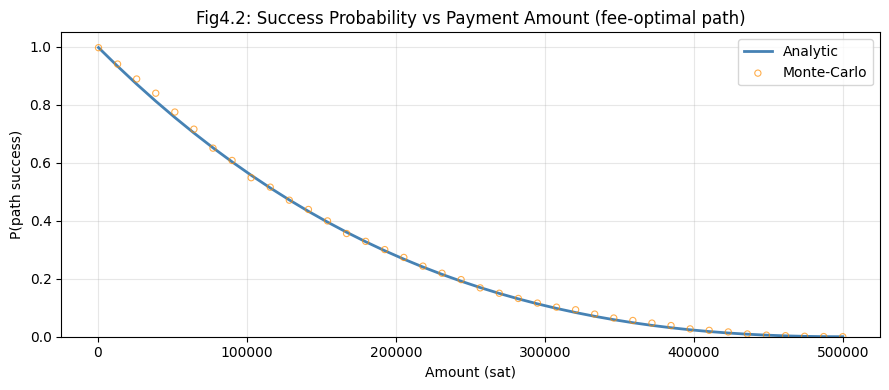

Bottleneck capacity along path: 500,000,000 msat (500,000 sat)
At  5% of bottleneck: analytic=0.877
At 50% of bottleneck: analytic=0.181


In [7]:
# Success vs amount sweep on the fee-optimal path
if n_nodes >= 2 and fee_route:
    path = fee_route["path"]

    # Smallest capacity along the path determines the maximum routable amount
    hop_caps = []
    for u, v in zip(path[:-1], path[1:]):
        best_cap = max(
            (int(data.get("capacity", 0)) * 1000
             for _, data in G[u][v].items()),
            default=0,
        )
        hop_caps.append(best_cap)
    bottleneck = min(hop_caps) if hop_caps else 0

    if bottleneck > 0:
        sweep_amounts = np.linspace(max(1, bottleneck // 1000), bottleneck, 40, dtype=int)
        analytic_ps = [liq.path_success_probability(G, path, int(a)) for a in sweep_amounts]
        mc_rates = [
            liq.monte_carlo_success_rate(G, path, int(a), n_trials=2_000, seed=SEED)
            for a in sweep_amounts
        ]

        fig, ax = plt.subplots(figsize=(9, 4))
        ax.plot(sweep_amounts / 1_000, analytic_ps, label="Analytic", lw=2, color="steelblue")
        ax.scatter(sweep_amounts / 1_000, mc_rates, label="Monte-Carlo",
                   facecolors="none", edgecolors="darkorange", s=20, alpha=0.7, linewidths=0.8, zorder=3)
        ax.set_xlabel("Amount (sat)")
        ax.set_ylabel("P(path success)")
        ax.set_title("Fig4.2: Success Probability vs Payment Amount (fee-optimal path)")
        ax.legend()
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        print(f"Bottleneck capacity along path: {bottleneck:,} msat ({bottleneck // 1000:,} sat)")
        print(f"At  5% of bottleneck: analytic={liq.path_success_probability(G, path, bottleneck // 20):.3f}")
        print(f"At 50% of bottleneck: analytic={liq.path_success_probability(G, path, bottleneck // 2):.3f}")
    else:
        bottleneck = 0
        print("Could not determine bottleneck capacity.")
else:
    bottleneck = 0
    print("No route available for sweep.")

## 5 · What reliability costs

Finally, sweep the payment amount and compare the two routing strategies side by side. The table shows, for each amount, the fee-optimal route's fee and success probability against the success-optimal route's probability.

The gap widens as payments grow. At **2,500 sat** both routes are near-certain (0.99 vs 0.997). At **100,000 sat** the fee-optimal route's success has fallen to **0.57 while the success-optimal route still holds 0.87**; at 250,000 sat it's **0.18 vs 0.70**. The two strategies pick **different paths at every amount** (`same_path = False` throughout). The takeaway for a sender: when a payment is small relative to channel sizes, just minimise fees — reliability is a non-issue. When it's large, paying a little more to route through deep-liquidity hubs buys a large jump in the odds it actually completes.

**Why splitting a large payment helps.** This same curve is the reason a sender (or wallet) can split a large payment into a few smaller amounts and improve reliability — the basis of **multi-path payments (MPP)**. A 250,000-sat payment sent in one shot succeeds only ~18% of the time on the fee-optimal path; a 100,000-sat amount succeeds ~57%, and a 2,500-sat one is near-certain. Break the payment into several smaller shards and route them over *different* paths and two things improve at once: each shard is small relative to channel capacity, so its per-hop success is higher by the $(C-A)/C$ model, and no single bottleneck channel has to carry the whole amount. The transfer completes when the shards arrive together, so spreading the load turns one unlikely large payment into several likely small ones — which is how modern Lightning wallets recover from a failed large payment by retrying it as smaller pieces.

In [8]:
if n_nodes >= 2:
    # Sweep 5 checkpoints from ~0.5% to ~50% of the bottleneck so the
    # fee/success divergence is visible at meaningful fractions of capacity.
    # Falls back to AMOUNT_MSAT-relative fractions if bottleneck is unknown.
    _btk = bottleneck if bottleneck > 0 else AMOUNT_MSAT * 20
    sweep_amounts = sorted(set([
        max(1_000, _btk // 200),   # ~0.5%
        max(1_000, _btk // 50),    # ~2%
        max(1_000, AMOUNT_MSAT),   # ~5% (the reference amount)
        max(1_000, _btk // 5),     # ~20%
        max(1_000, _btk // 2),     # ~50%
    ]))

    rows = []
    for amt in sweep_amounts:
        fr = rte.find_route(G, src, dst, amount_msat=amt)
        sr = liq.success_optimal_route(G, src, dst, amount_msat=amt)

        fee_p = liq.path_success_probability(G, fr["path"], amt) if fr else 0.0
        suc_p = sr["success_probability"] if sr else 0.0
        fee_cost = fr["total_fee_msat"] if fr else None
        same_path = (fr["path"] == sr["path"]) if (fr and sr) else True

        rows.append({
            "amount_sat": amt // 1000,
            "fee_route_fee_msat": fee_cost,
            "fee_route_success_P": round(fee_p, 4),
            "suc_route_success_P": round(suc_p, 4),
            "same_path": same_path,
        })

    df_cmp = pd.DataFrame(rows)
    print(df_cmp.to_string(index=False))
else:
    print("Need at least 2 nodes.")

 amount_sat  fee_route_fee_msat  fee_route_success_P  suc_route_success_P  same_path
       2500               115.0               0.9860               0.9968      False
      10000               260.0               0.9454               0.9871      False
     100000              2400.0               0.5675               0.8742      False
     125000              2750.0               0.4832               0.8441      False
     250000              4500.0               0.1808               0.7008      False


## Summary

**Model**: uniform prior on channel balance → $P(\text{hop}) = (C - A) / C$  
**Path success**: product of per-hop probabilities  
**success-optimal routing**: Dijkstra on $-\log P$ (maximises $\prod P_i$)  
**Monte-Carlo**: empirical validation converges to the analytic model  

Key insights:
- Success probability drops steeply as payment amount approaches channel capacity.
- Multi-hop paths compound the individual failure risks — even 90% per-hop becomes
  65% over 4 hops. Shorter paths are more reliable, not just cheaper.
- The success-optimal route diverges from the fee-optimal route when cheap channels
  have low capacity. The trade-off is quantifiable: how much extra fee buys what
  improvement in reliability?
- The Monte-Carlo matches the analytic model within statistical noise, validating
  the uniform-prior assumption as a useful baseline.
- Because success rises steeply as amount/capacity falls, **splitting a large payment
  into a few smaller shards over different paths** (multi-path payments, MPP) raises the
  odds of completion and is how wallets overcome large-payment failures: each shard is
  more likely to fit, and no single channel carries the whole amount.

Extensions:
- Bayesian balance update: after observing a payment failure at hop $i$, update the
  posterior for that channel's balance (the real-router direction — Pickhardt et al.).
- Success-weighted fee optimisation: minimise $\text{fee} / P(\text{path})$ rather
  than fee or probability alone.